This notebook can be used to run the best two models on the test set

In [1]:
!git clone https://github.com/nasoskar/NLP.git
%cd NLP

Cloning into 'NLP'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 73 (delta 35), reused 59 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 527.95 KiB | 3.74 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/NLP


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import torch
import pickle
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

from dataset import clean_text, LSTMClassification, FinBertDataset, build_vocab
from svm import SVM_Classifier
from lstm import LSTM
from finbert import FINBERT
from config import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


Load the test set

In [9]:
test_df = pd.read_csv("/content/drive/MyDrive/NLP/test.csv")
print(f"Test set loaded: {test_df.shape}")
print(test_df.head())

Test set loaded: (1539, 2)
                                                text  label
0  finnish exel composites , a technology company...      0
1  should you think about buying nv5 global, inc....      2
2  boomeranger boats oy specialises in boat build...      2
3  the combination of all services enabling us to...      1
4     canadian national railway on watch amid strike      2


In [10]:
test_df["text"] = test_df["text"].apply(clean_text)

X_test = test_df["text"]
y_test = test_df["label"]

print(f"Test samples: {len(X_test)}")
print(f"Label distribution:\n{y_test.value_counts()}")

Test samples: 1539
Label distribution:
label
2    989
1    329
0    221
Name: count, dtype: int64


Best SVM params: {'C': 1, 'kernel': 'rbf'}

SVM — Test Results
Accuracy:  0.834
Macro F1:  0.768
Precision: 0.794
Recall:    0.749

              precision    recall  f1-score   support

    Negative       0.76      0.59      0.66       221
    Positive       0.75      0.74      0.74       329
     Neutral       0.87      0.92      0.90       989

    accuracy                           0.83      1539
   macro avg       0.79      0.75      0.77      1539
weighted avg       0.83      0.83      0.83      1539



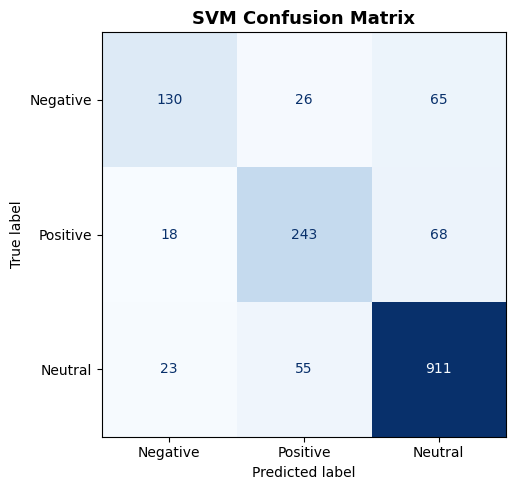

In [12]:
with open("/content/drive/MyDrive/NLP/checkpoints/best_svm.pkl", "rb") as f:
    saved = pickle.load(f)

vectorizer = saved["vectorizer"]
classifier = saved["classifier"]
print("Best SVM params:", saved["best_params"])

# predict
X_test_tfidf = vectorizer.transform(X_test)
y_pred_svm = classifier.predict(X_test_tfidf)

# results
print("\n" + "=" * 50)
print("SVM — Test Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.3f}")
print(f"Macro F1:  {f1_score(y_test, y_pred_svm, average='macro'):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, average='macro'):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm, average='macro'):.3f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=["Negative", "Positive", "Neutral"]))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive", "Neutral"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("SVM Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

FinBERT loaded successfully


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


FinBERT — Test Results
Accuracy:  0.873
Macro F1:  0.844
Precision: 0.820
Recall:    0.879

              precision    recall  f1-score   support

    Negative       0.74      0.86      0.80       221
    Positive       0.75      0.91      0.82       329
     Neutral       0.97      0.86      0.91       989

    accuracy                           0.87      1539
   macro avg       0.82      0.88      0.84      1539
weighted avg       0.89      0.87      0.88      1539



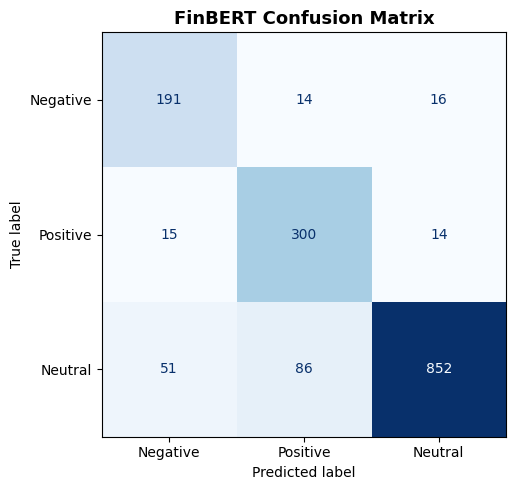

In [13]:
# best params from training
FINBERT_BEST_PARAMS = {"dropout": 0.1, "lr": 3e-5}

model_finbert = FINBERT(dropout=FINBERT_BEST_PARAMS["dropout"]).to(device)
checkpoint = torch.load("/content/drive/MyDrive/NLP/checkpoints/best_finbert_overall.pth", map_location=device)
model_finbert.load_state_dict(checkpoint)
model_finbert.eval()
print("FinBERT loaded successfully")

# create dataloader
test_dataset = FinBertDataset(X_test.reset_index(drop=True), y_test.reset_index(drop=True))
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# predict
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)
        output = model_finbert(input_ids, attention_mask)
        preds = torch.argmax(output, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# results
print("\n" + "=" * 50)
print("FinBERT — Test Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(all_labels, all_preds):.3f}")
print(f"Macro F1:  {f1_score(all_labels, all_preds, average='macro'):.3f}")
print(f"Precision: {precision_score(all_labels, all_preds, average='macro'):.3f}")
print(f"Recall:    {recall_score(all_labels, all_preds, average='macro'):.3f}")
print()
print(classification_report(all_labels, all_preds, target_names=["Negative", "Positive", "Neutral"]))

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive", "Neutral"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("FinBERT Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()